# Interactive napari viewer — cell type annotations

Load the cell-type-annotated SpatialData object directly from Zarr and open an interactive napari session: morphology image, H&E image, and cell points colored by `cell_type`.

In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Qt/OpenGL settings for Ubuntu + Wayland
os.environ["QT_QPA_PLATFORM"] = "xcb"
os.environ["PYOPENGL_PLATFORM"] = "glx"

import napari
import spatialdata as sd

In [2]:
PROJECT = Path.home() / "Projects/xenium_lung"
SDATA_PATH = PROJECT / "data/spatialdata/xenium_prime_5k_processed_annotated.zarr"

print("SpatialData path:", SDATA_PATH)
print("Exists:", SDATA_PATH.exists())

SpatialData path: /home/duydao/Projects/xenium_lung/data/spatialdata/xenium_prime_5k_processed_annotated.zarr
Exists: True


## Load the SpatialData object

In [3]:
sdata = sd.read_zarr(SDATA_PATH)
sdata

no parent found for <ome_zarr.reader.Label object at 0x7088fd5fe1b0>: None
no parent found for <ome_zarr.reader.Label object at 0x7088fd5ffe00>: None


SpatialData object, with associated Zarr store: /home/duydao/Projects/xenium_lung/data/spatialdata/xenium_prime_5k_processed_annotated.zarr
├── Images
│     ├── 'he_image': DataTree[cyx] (3, 43270, 26720), (3, 21635, 13360), (3, 10817, 6680), (3, 5408, 3340), (3, 2704, 1670)
│     └── 'morphology_focus': DataTree[cyx] (4, 37348, 54086), (4, 18674, 27043), (4, 9337, 13521), (4, 4668, 6760), (4, 2334, 3380)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (37348, 54086), (18674, 27043), (9337, 13521), (4668, 6760), (2334, 3380)
│     └── 'nucleus_labels': DataTree[yx] (37348, 54086), (18674, 27043), (9337, 13521), (4668, 6760), (2334, 3380)
├── Points
│     └── 'transcripts': DataFrame with shape: (177464221, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (278328, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (277935, 3) (2D shapes)
└── Tables
      └── 'table': AnnData (266179, 4860)
with coordinate systems:
    ▸ 'global', with elements

## Extract the cell table (cell_type, spatial coordinates)

In [4]:
adata = sdata.tables["table"]

print("Cells:", adata.n_obs)
print("cell_type categories:")
print(adata.obs["cell_type"].value_counts())

Cells: 266179
cell_type categories:
cell_type
EC                  41590
Tumor_epithelial    38618
Fibroblast          33666
Treg                31717
Macrophage          25977
SMC/MC              15938
Neutrophil          14954
Ciliated            11179
T_cytotoxic         10247
Plasma               9999
B_cell               9740
AT1                  8916
AT2                  8752
Mast                 3902
PNECs                 984
Name: count, dtype: int64


In [5]:
# obsm["spatial"] is in the same raw (micron) units as the shapes/points elements —
# it needs the same scale transform as cell_boundaries to align with the pixel-space images.
from spatialdata.transformations import get_transformation

boundaries_transform = get_transformation(sdata.shapes["cell_boundaries"], to_coordinate_system="global")
scale_matrix = boundaries_transform.to_affine_matrix(input_axes=("x", "y"), output_axes=("x", "y"))

# Micron size of one pixel in the shared "global" pixel space (all layers use this same factor).
PIXEL_SIZE_UM = 1 / scale_matrix[0, 0]

print(scale_matrix)
print("Pixel size:", PIXEL_SIZE_UM, "µm/px")

[[4.70588235 0.         0.        ]
 [0.         4.70588235 0.        ]
 [0.         0.         1.        ]]
Pixel size: 0.2125 µm/px


In [6]:
raw_xy = adata.obsm["spatial"]

homogeneous = np.column_stack([raw_xy, np.ones(len(raw_xy))])
global_xy = (scale_matrix @ homogeneous.T).T[:, :2]

print("Raw spatial range:", raw_xy.min(axis=0), raw_xy.max(axis=0))
print("Global (pixel-space) range:", global_xy.min(axis=0), global_xy.max(axis=0))

Raw spatial range: [  9.38428116 145.14759827] [11467.05078125  7783.51318359]
Global (pixel-space) range: [ 44.1613231  683.04752125] [53962.59191176 36628.29733456]


## Build a categorical color map for `cell_type`

In [7]:
cell_types = adata.obs["cell_type"].astype(str).to_numpy()
categories = sorted(pd.unique(cell_types))

cmap = plt.get_cmap("tab20", len(categories))
color_cycle = [cmap(i) for i in range(len(categories))]

print("cell_type categories:", categories)

cell_type categories: ['AT1', 'AT2', 'B_cell', 'Ciliated', 'EC', 'Fibroblast', 'Macrophage', 'Mast', 'Neutrophil', 'PNECs', 'Plasma', 'SMC/MC', 'T_cytotoxic', 'Treg', 'Tumor_epithelial']


## Quicklook: confirm point cloud aligns with image extent

morphology_focus s0 shape (c, y, x): (4, 37348, 54086)


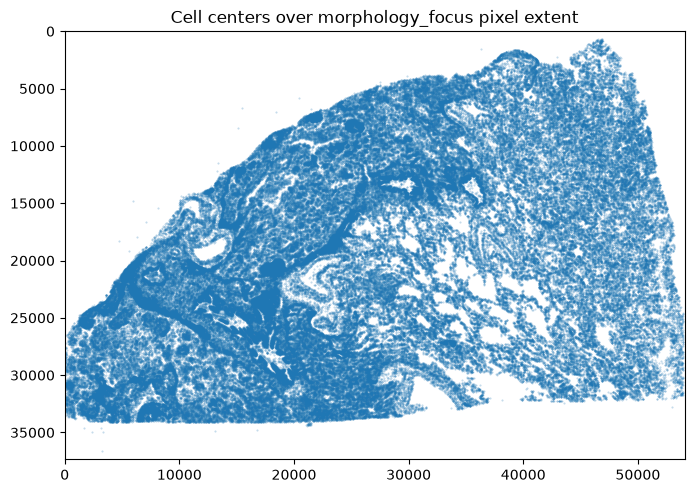

In [8]:
morphology_s0_shape = sdata.images["morphology_focus"]["scale0"]["image"].shape
print("morphology_focus s0 shape (c, y, x):", morphology_s0_shape)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(global_xy[:, 0], global_xy[:, 1], s=0.2, alpha=0.3)
ax.set_xlim(0, morphology_s0_shape[-1])
ax.set_ylim(morphology_s0_shape[-2], 0)
ax.set_aspect("equal")
ax.set_title("Cell centers over morphology_focus pixel extent")
plt.show()

If the point cloud does not fill the plotted extent, the transform above needs revisiting before trusting the napari overlay.

## Open napari

In [9]:
viewer = napari.Viewer()

/home/duydao/micromamba/envs/spatial_env/lib/python3.12/site-packages/napari/_qt/qt_event_loop.py:49: UserWarning: System theme detection requires a Qt6 backend. Please switch to PyQt6 or PySide6 to use it.
  theme_type=get_system_theme(),
/home/duydao/micromamba/envs/spatial_env/lib/python3.12/site-packages/napari/_qt/qt_event_loop.py:49: UserWarning: System theme detection requires a Qt6 backend. Please switch to PyQt6 or PySide6 to use it.
  theme_type=get_system_theme(),


## Add the morphology multiscale image

In [10]:
morphology = sdata.images["morphology_focus"]
scale_keys = sorted(morphology.keys())

morphology_pyramid = [morphology[key]["image"].data for key in scale_keys]
channel_names = list(morphology[scale_keys[0]]["image"].coords["c"].values)

print("Pyramid levels:", [level.shape for level in morphology_pyramid])
print("Channels:", channel_names)

Pyramid levels: [(4, 37348, 54086), (4, 18674, 27043), (4, 9337, 13521), (4, 4668, 6760), (4, 2334, 3380)]
Channels: [np.str_('DAPI'), np.str_('ATP1A1/CD45/E-Cadherin'), np.str_('18S'), np.str_('AlphaSMA/Vimentin')]


In [11]:
viewer.add_image(
    morphology_pyramid,
    multiscale=True,
    channel_axis=0,
    name=channel_names,
    contrast_limits=[0, 20000],
    scale=(PIXEL_SIZE_UM, PIXEL_SIZE_UM),
    units=("um", "um"),
    visible=False,
)

[<Image layer 'DAPI' at 0x7088fd6d6060>,
 <Image layer 'ATP1A1/CD45/E-Cadherin' at 0x708836ff2b40>,
 <Image layer '18S' at 0x708834541670>,
 <Image layer 'AlphaSMA/Vimentin' at 0x70883455d280>]

## Add the H&E image

In [12]:
he_image = sdata.images["he_image"]
he_scale_keys = sorted(he_image.keys())

he_pyramid = [
    he_image[key]["image"].transpose("y", "x", "c").data
    for key in he_scale_keys
]

print("H&E pyramid levels:", [level.shape for level in he_pyramid])

# Alignment CSV is a (x, y, 1) affine mapping full-res H&E pixels -> global (morphology) pixel space.
he_align_path = PROJECT / "data/bundle/xenium_prime_5k/Xenium_Prime_Human_Lung_Cancer_FFPE_he_imagealignment.csv"
he_affine_xy = pd.read_csv(he_align_path, header=None).to_numpy()

a, b, tx = he_affine_xy[0]
c, d, ty = he_affine_xy[1]

# Reorder rows/cols from (x, y) to napari's (y, x) axis convention.
he_affine_yx = np.array(
    [
        [d, c, ty],
        [b, a, tx],
        [0, 0, 1],
    ]
)

# Scale the affine's linear part and translation together so its output is in microns, matching every other layer.
he_affine_um = he_affine_yx.copy()
he_affine_um[:2, :] *= PIXEL_SIZE_UM

viewer.add_image(
    he_pyramid,
    multiscale=True,
    rgb=True,
    affine=he_affine_um,
    units=("um", "um"),
    name="H&E",
    visible=True,
)

H&E pyramid levels: [(43270, 26720, 3), (21635, 13360, 3), (10817, 6680, 3), (5408, 3340, 3), (2704, 1670, 3)]


<Image layer 'H&E' at 0x7088fd6d6570>

## Add cell boundary polygons filled by `cell_type`

Cap the number of polygons rendered at once (napari's shapes layer gets slow well before ~266k polygons); raise `N_POLYGONS` if performance allows.

In [13]:
N_POLYGONS = 30_000

boundaries = sdata.shapes["cell_boundaries"].iloc[:N_POLYGONS]

polygon_data = []
polygon_cell_types = []

cell_type_lookup = pd.Series(cell_types, index=adata.obs["cell_labels"].astype(str).to_numpy())

for cell_id, geom in zip(boundaries.index, boundaries["geometry"]):
    coords = np.asarray(geom.exterior.coords)

    coords_h = np.column_stack([coords, np.ones(len(coords))])
    coords_global = (scale_matrix @ coords_h.T).T[:, :2]

    # X,Y -> Y,X for napari
    coords_yx = coords_global[:, [1, 0]]

    polygon_data.append(coords_yx)
    polygon_cell_types.append(cell_type_lookup.get(str(cell_id), "unknown"))

# Include "unknown" as its own category so no polygon lookup falls back to NaN.
shape_categories = categories + ["unknown"] if "unknown" in polygon_cell_types else categories
shape_color_cycle = color_cycle + [(0.5, 0.5, 0.5, 1.0)] if "unknown" in polygon_cell_types else color_cycle

print("Polygons:", len(polygon_data))
print("Unmatched (unknown):", polygon_cell_types.count("unknown"))

Polygons: 30000
Unmatched (unknown): 514


In [14]:
viewer.add_shapes(
    polygon_data,
    shape_type="polygon",
    properties={"cell_type": pd.Categorical(polygon_cell_types, categories=shape_categories)},
    edge_width=0,
    face_color="cell_type",
    face_color_cycle=shape_color_cycle,
    scale=(PIXEL_SIZE_UM, PIXEL_SIZE_UM),
    units=("um", "um"),
    name=f"Cell boundaries — {N_POLYGONS:,}",
    visible=True,
)

<Shapes layer 'Cell boundaries — 30,000' at 0x70881f9e3740>

## Hover tooltip showing `cell_type`

In [15]:
shapes_layer = viewer.layers[f"Cell boundaries — {N_POLYGONS:,}"]

viewer.text_overlay.visible = True
viewer.text_overlay.color = "white"
viewer.text_overlay.font_size = 12


@shapes_layer.mouse_move_callbacks.append
def show_cell_type_tooltip(layer, event):
    shape_index = layer.get_value(
        event.position,
        view_direction=event.view_direction,
        dims_displayed=event.dims_displayed,
        world=True,
    )
    if isinstance(shape_index, tuple):
        shape_index = shape_index[0]

    if shape_index is not None:
        cell_type = layer.properties["cell_type"][shape_index]
        viewer.text_overlay.text = f"cell_type: {cell_type}"
    else:
        viewer.text_overlay.text = ""

## Show the scale bar in microns instead of pixels

Every layer above was already created with a `scale`/`affine` baked in at `PIXEL_SIZE_UM`, so this just switches the scale bar's label — no post-hoc layer mutation needed.

In [16]:
viewer.scale_bar.visible = True